In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from hmmlearn.hmm import GaussianHMM
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Ricarica i dati e riallenamento modello
returns_eu = pd.read_csv(
    r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_europe.csv',
    index_col=0, parse_dates=True
)
market_returns = returns_eu.mean(axis=1)

# Feature engineering
def make_features(returns):
    f = pd.DataFrame(index=returns.index)
    f['returns'] = returns
    f['vol_21']  = returns.rolling(21).std() * np.sqrt(252)
    f['vol_63']  = returns.rolling(63).std() * np.sqrt(252)
    f['momentum_21'] = returns.rolling(21).sum()
    f['momentum_63'] = returns.rolling(63).sum()
    f['drawdown'] = returns.cumsum() - returns.cumsum().cummax()
    return f.dropna()

features = make_features(market_returns)

# Riallenamento HMM
X_hmm = features[['returns', 'vol_21']].values
model = GaussianHMM(n_components=4, covariance_type='diag',
                    n_iter=1000, random_state=42)
model.fit(X_hmm)

# Mappa stati
states = model.predict(X_hmm)
state_vols = {i: X_hmm[states == i, 1].mean() for i in range(4)}
vol_sorted = sorted(state_vols.items(), key=lambda x: x[1])
state_names = {
    vol_sorted[0][0]: 'CHOP',
    vol_sorted[1][0]: 'BULL',
    vol_sorted[2][0]: 'BEAR',
    vol_sorted[3][0]: 'HIGH-VOL'
}
colors = {'BULL': '#2ecc71', 'BEAR': '#e74c3c', 
          'HIGH-VOL': '#e67e22', 'CHOP': '#95a5a6'}

features['regime'] = [state_names[s] for s in states]
print("Modello riallenato.")
print(f"Dati fino a: {features.index[-1].date()}")

Model is not converging.  Current: 15818.188709962877 is not greater than 15818.32127620995. Delta is -0.13256624707355513


Modello riallenato.
Dati fino a: 2025-12-31


In [2]:
# Cella 1 — Download dati aggiornati e classificazione oggi

def update_market_data(tickers, lookback_days=60):
    """Scarica dati recenti e calcola rendimento mercato aggiornato"""
    end = datetime.today()
    start = end - timedelta(days=lookback_days)
    
    prices = yf.download(tickers, start=start, end=end, 
                         auto_adjust=True, progress=False)['Close']
    returns = prices.pct_change().dropna()
    market = returns.mean(axis=1)
    return market

# Tickers europei
eu_tickers = list(returns_eu.columns)

print("Scaricando dati aggiornati...")
recent_returns = update_market_data(eu_tickers, lookback_days=90)

# Unisci con storico per avere abbastanza dati per le feature
full_returns = pd.concat([market_returns, recent_returns])
full_returns = full_returns[~full_returns.index.duplicated(keep='last')]
full_returns = full_returns.sort_index()

# Ricalcola feature sull'intero dataset aggiornato
features_live = make_features(full_returns)

# Classifica tutto il dataset aggiornato
X_live = features_live[['returns', 'vol_21']].values
states_live = model.predict(X_live)
probs_live = model.predict_proba(X_live)

features_live['regime'] = [state_names[s] for s in states_live]

# ── REGIME CORRENTE ──────────────────────────────────────────────
today_features = features_live.iloc[-1]
today_probs = probs_live[-1]

current_regime = today_features['regime']
current_vol = today_features['vol_21']
current_momentum = today_features['momentum_63']

# Probabilità per regime
regime_probs = {state_names[i]: today_probs[i] for i in range(4)}
regime_probs_sorted = dict(sorted(regime_probs.items(), 
                                   key=lambda x: x[1], reverse=True))

print("\n" + "="*55)
print("  MARKET REGIME CLASSIFIER — LIVE")
print("="*55)
print(f"  Data:              {features_live.index[-1].date()}")
print(f"  Regime Corrente:   {current_regime}")
print(f"  Volatilità (ann.): {current_vol:.1%}")
print(f"  Momentum 63d:      {current_momentum:+.3f}")
print("-"*55)
print("  Probabilità per Regime:")
for regime, prob in regime_probs_sorted.items():
    bar = '█' * int(prob * 30)
    print(f"  {regime:<12} {prob:.1%}  {bar}")
print("="*55)

# Ultimi 5 giorni
print("\nUltimi 5 giorni:")
print(f"{'Data':<14} {'Regime':<12} {'P(BULL)':>8} {'P(BEAR)':>8} {'Vol':>8}")
print("-"*52)
for i in range(-5, 0):
    date = features_live.index[i]
    regime = features_live['regime'].iloc[i]
    p_bull = probs_live[i, [k for k,v in state_names.items() if v=='BULL'][0]]
    p_bear = probs_live[i, [k for k,v in state_names.items() if v=='BEAR'][0]]
    vol = features_live['vol_21'].iloc[i]
    print(f"{str(date.date()):<14} {regime:<12} {p_bull:>8.1%} {p_bear:>8.1%} {vol:>8.1%}")

Scaricando dati aggiornati...

  MARKET REGIME CLASSIFIER — LIVE
  Data:              2026-04-20
  Regime Corrente:   BEAR
  Volatilità (ann.): 18.4%
  Momentum 63d:      +0.039
-------------------------------------------------------
  Probabilità per Regime:
  BEAR         99.9%  █████████████████████████████
  HIGH-VOL     0.1%  
  BULL         0.0%  
  CHOP         0.0%  

Ultimi 5 giorni:
Data           Regime        P(BULL)  P(BEAR)      Vol
----------------------------------------------------
2026-04-10     BEAR             0.0%   100.0%    19.2%
2026-04-15     BEAR             0.0%   100.0%    19.0%
2026-04-16     BEAR             0.0%   100.0%    18.5%
2026-04-17     BEAR             0.0%   100.0%    18.7%
2026-04-20     BEAR             0.0%    99.9%    18.4%


In [3]:
# Cella 2 — Position Sizing condizionato al regime + Alert System

# Regole di position sizing per regime
SIZING_RULES = {
    'BULL':     {'position': 1.00, 'leverage': 1.0,  'color': '#2ecc71'},
    'CHOP':     {'position': 0.60, 'leverage': 0.6,  'color': '#95a5a6'},
    'BEAR':     {'position': 0.00, 'leverage': 0.0,  'color': '#e74c3c'},
    'HIGH-VOL': {'position': -0.30,'leverage': -0.3, 'color': '#e67e22'},
}

# Volatility targeting overlay
VOL_TARGET = 0.15  # 15% annualizzata target
current_position = SIZING_RULES[current_regime]['position']
vol_scalar = min(VOL_TARGET / current_vol, 2.0)  # cap a 2x
final_position = current_position * vol_scalar

# Alert system
bull_state = [k for k,v in state_names.items() if v=='BULL'][0]
bear_state  = [k for k,v in state_names.items() if v=='BEAR'][0]
hv_state    = [k for k,v in state_names.items() if v=='HIGH-VOL'][0]

p_bull_today = regime_probs['BULL']
p_bear_today = regime_probs['BEAR']
p_hv_today   = regime_probs['HIGH-VOL']

# Transizione regime negli ultimi 5 giorni
recent_regimes = features_live['regime'].iloc[-10:].values
regime_changed = recent_regimes[-1] != recent_regimes[-6]
days_in_regime = 1
for r in reversed(recent_regimes[:-1]):
    if r == recent_regimes[-1]:
        days_in_regime += 1
    else:
        break

print("="*55)
print("  POSITION SIZING & RISK MANAGEMENT")
print("="*55)
print(f"  Regime:            {current_regime}")
print(f"  Base Position:     {current_position:+.0%}")
print(f"  Vol Scalar:        {vol_scalar:.2f}x  (target {VOL_TARGET:.0%} / actual {current_vol:.1%})")
print(f"  Final Position:    {final_position:+.1%}")
print(f"  Giorni nel regime: {days_in_regime}")
print("-"*55)
print("  ALERT SYSTEM:")

alerts = []
if p_bear_today > 0.30 and current_regime != 'BEAR':
    alerts.append(f"⚠️  ATTENZIONE: P(BEAR) = {p_bear_today:.1%} — ridurre esposizione")
if p_hv_today > 0.20 and current_regime not in ['BEAR', 'HIGH-VOL']:
    alerts.append(f"⚠️  VOLATILITÀ: P(HIGH-VOL) = {p_hv_today:.1%} — hedge consigliato")
if regime_changed:
    old_regime = recent_regimes[-6]
    alerts.append(f"🔄  CAMBIO REGIME: {old_regime} → {current_regime} negli ultimi 5 giorni")
if current_vol > 0.25:
    alerts.append(f"📊  ALTA VOL: {current_vol:.1%} annualizzata — position size ridotto automaticamente")
if days_in_regime >= 20:
    alerts.append(f"✅  REGIME STABILE: {days_in_regime} giorni consecutivi in {current_regime}")
if not alerts:
    alerts.append("✅  Nessun alert — condizioni nella norma")

for alert in alerts:
    print(f"  {alert}")

print("="*55)
print(f"\n  RACCOMANDAZIONE:")
if current_regime == 'BULL':
    print(f"  → Long {final_position:.0%} del portafoglio")
elif current_regime == 'CHOP':
    print(f"  → Long ridotto {final_position:.0%} — mercato laterale")
elif current_regime == 'BEAR':
    print(f"  → FLAT — zero esposizione al mercato")
    print(f"  → Considera protezione con put options o short ETF")
elif current_regime == 'HIGH-VOL':
    print(f"  → Short {abs(final_position):.0%} — regime di crisi")
    print(f"  → Massima attenzione ai risk limits")

  POSITION SIZING & RISK MANAGEMENT
  Regime:            BEAR
  Base Position:     +0%
  Vol Scalar:        0.82x  (target 15% / actual 18.4%)
  Final Position:    +0.0%
  Giorni nel regime: 10
-------------------------------------------------------
  ALERT SYSTEM:
  ✅  Nessun alert — condizioni nella norma

  RACCOMANDAZIONE:
  → FLAT — zero esposizione al mercato
  → Considera protezione con put options o short ETF


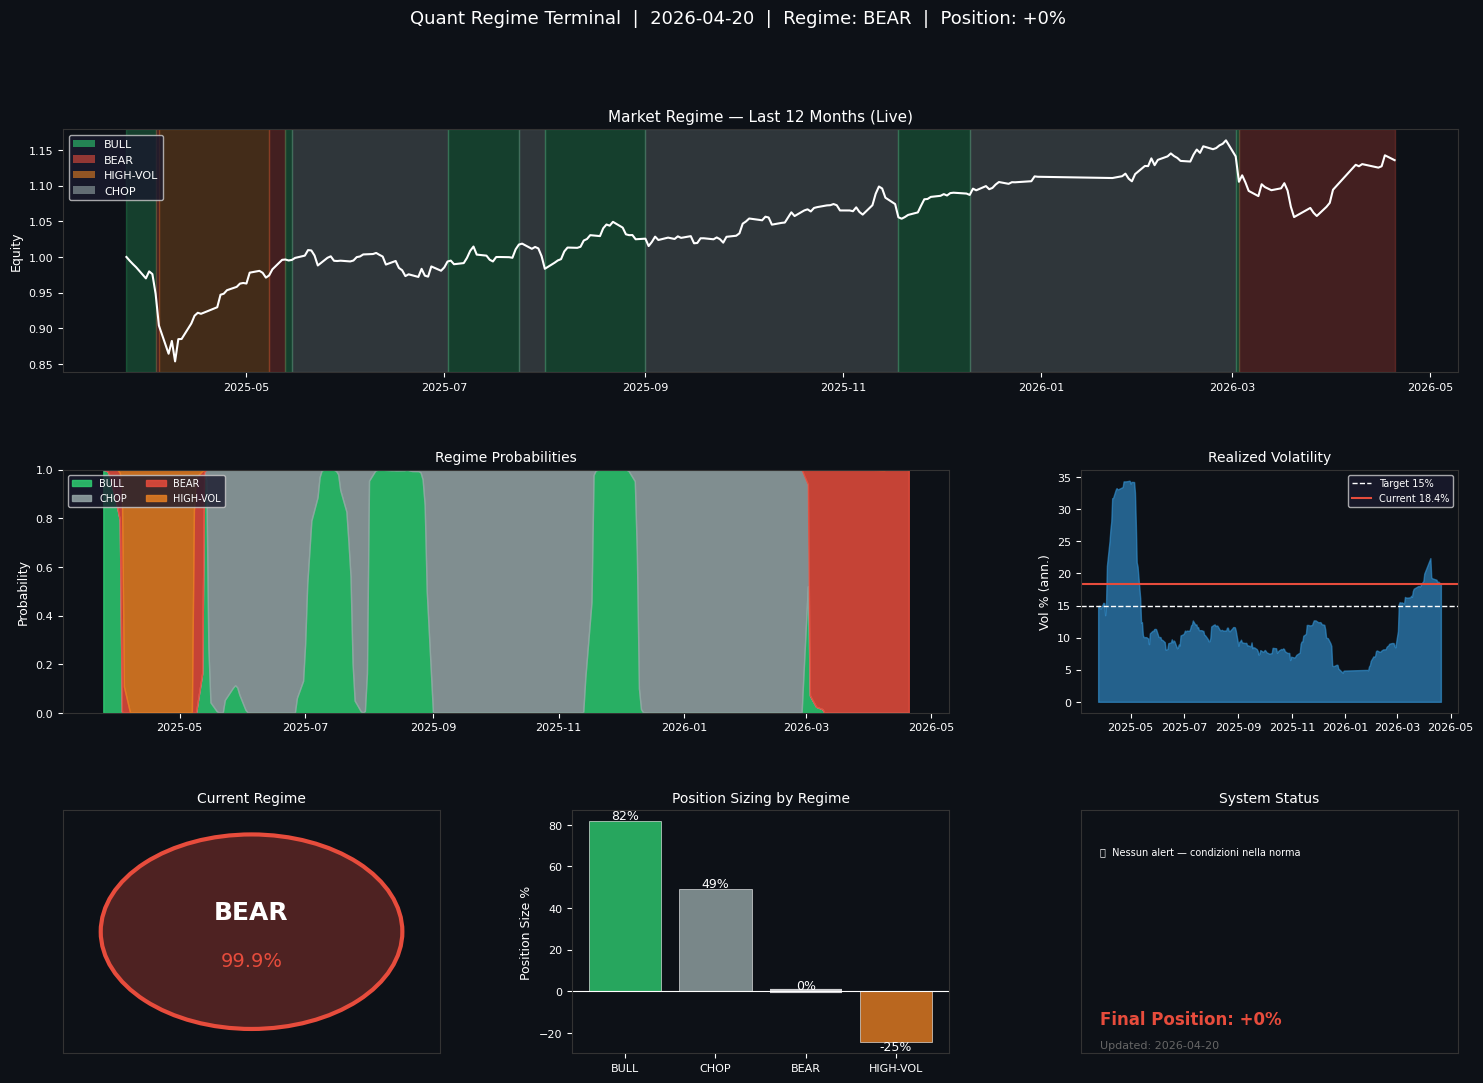

In [4]:
# Cella 3 — Live Dashboard

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# Ultimi 252 giorni (1 anno)
lookback = 252
recent = features_live.iloc[-lookback:]
recent_probs = probs_live[-lookback:]
recent_equity = (1 + full_returns.reindex(recent.index)).cumprod()
recent_equity = recent_equity / recent_equity.iloc[0]

def style_ax(ax):
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#333')

# ── Panel 1 (top, full width) — Equity + regime bands ──────────
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1)
ax1.plot(recent_equity.index, recent_equity.values,
         color='white', linewidth=1.5, zorder=3)

prev, start_d = None, recent.index[0]
for date, row in recent.iterrows():
    r = row['regime']
    if r != prev:
        if prev:
            ax1.axvspan(start_d, date, alpha=0.25, color=colors[prev])
        start_d, prev = date, r
ax1.axvspan(start_d, recent.index[-1], alpha=0.25, color=colors[prev])

ax1.set_title('Market Regime — Last 12 Months (Live)', 
              color='white', fontsize=11)
ax1.set_ylabel('Equity', color='white', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.6, label=r) 
                   for r, c in colors.items()]
ax1.legend(handles=legend_elements, loc='upper left',
           facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# ── Panel 2 — Regime probabilities stacked ─────────────────────
ax2 = fig.add_subplot(gs[1, :2])
style_ax(ax2)

bottom = np.zeros(len(recent))
for regime in ['BULL', 'CHOP', 'BEAR', 'HIGH-VOL']:
    state = [k for k,v in state_names.items() if v==regime][0]
    ax2.fill_between(recent.index, bottom,
                     bottom + recent_probs[:, state],
                     color=colors[regime], alpha=0.85, label=regime)
    bottom += recent_probs[:, state]

ax2.set_title('Regime Probabilities', color='white', fontsize=10)
ax2.set_ylabel('Probability', color='white', fontsize=9)
ax2.set_ylim(0, 1)
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=7,
           loc='upper left', ncol=2)

# ── Panel 3 — Volatilità realizzata ────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
style_ax(ax3)
ax3.fill_between(recent.index, recent['vol_21'] * 100,
                 color='#3498db', alpha=0.6)
ax3.axhline(y=VOL_TARGET*100, color='white', linestyle='--',
            linewidth=1, label=f'Target {VOL_TARGET:.0%}')
ax3.axhline(y=current_vol*100, color='#e74c3c', linestyle='-',
            linewidth=1.5, label=f'Current {current_vol:.1%}')
ax3.set_title('Realized Volatility', color='white', fontsize=10)
ax3.set_ylabel('Vol % (ann.)', color='white', fontsize=9)
ax3.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=7)

# ── Panel 4 — Gauge regime corrente ────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
style_ax(ax4)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.set_xticks([])
ax4.set_yticks([])

regime_color = colors[current_regime]
circle = plt.Circle((0.5, 0.5), 0.4, color=regime_color, alpha=0.3)
circle2 = plt.Circle((0.5, 0.5), 0.4, fill=False, 
                      color=regime_color, linewidth=3)
ax4.add_patch(circle)
ax4.add_patch(circle2)
ax4.text(0.5, 0.58, current_regime, ha='center', va='center',
         color='white', fontsize=18, fontweight='bold')
ax4.text(0.5, 0.38, f'{p_bear_today:.1%}', ha='center', va='center',
         color=regime_color, fontsize=14)
ax4.set_title('Current Regime', color='white', fontsize=10)

# ── Panel 5 — Position sizing ───────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
style_ax(ax5)

regimes_list = ['BULL', 'CHOP', 'BEAR', 'HIGH-VOL']
positions = [SIZING_RULES[r]['position'] * 
             min(VOL_TARGET / current_vol, 2.0) for r in regimes_list]
bar_colors = [colors[r] for r in regimes_list]
bars = ax5.bar(regimes_list, [p*100 for p in positions],
               color=bar_colors, alpha=0.8, edgecolor='white', linewidth=0.5)

for bar, pos in zip(bars, positions):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (1 if pos >= 0 else -4),
             f'{pos:.0%}', ha='center', color='white', fontsize=9)

ax5.axhline(y=0, color='white', linewidth=0.8)
ax5.set_title('Position Sizing by Regime', color='white', fontsize=10)
ax5.set_ylabel('Position Size %', color='white', fontsize=9)
ax5.tick_params(axis='x', colors='white', labelsize=8)

# Evidenzia regime corrente
current_idx = regimes_list.index(current_regime)
bars[current_idx].set_edgecolor('white')
bars[current_idx].set_linewidth(3)

# ── Panel 6 — Alert summary ─────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
style_ax(ax6)
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.set_xticks([])
ax6.set_yticks([])
ax6.set_title('System Status', color='white', fontsize=10)

y_pos = 0.85
for alert in alerts:
    ax6.text(0.05, y_pos, alert, color='white', fontsize=7,
             va='top', wrap=True)
    y_pos -= 0.18

ax6.text(0.05, 0.12, f'Final Position: {final_position:+.0%}',
         color=regime_color, fontsize=12, fontweight='bold')
ax6.text(0.05, 0.02, f'Updated: {features_live.index[-1].date()}',
         color='#666', fontsize=8)

plt.suptitle(
    f'Quant Regime Terminal  |  {features_live.index[-1].date()}  |  '
    f'Regime: {current_regime}  |  Position: {final_position:+.0%}',
    color='white', fontsize=13, y=0.98
)

plt.savefig('../results/live_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()